# Notebook 09 - MVP 4-IW: Identity-Weighted Cross-Modal Attention

**Purpose.** Test the project's novel implementation contribution: explicitly biasing
cross-modal attention toward identity-laden tokens (using a HateXplain-derived lexicon
of 1,177 tokens) improves hate speech detection beyond the standard cross-attention used
in MVP 4. The hypothesis is that an additive identity-bias term `+ lambda_id * identity_mask`
in the attention logits, with `lambda_id` learnable scalar, will (a) demonstrate that the
model can use prior knowledge about identity terms when routing attention, and (b) yield
improvement on at least one of AUC, FPR, or interpretability (over-indexing on identity
tokens vs the uniform baseline) relative to MVP 4 (NB 08).

**Baselines to beat (test, balanced 50/50, thr=0.5):**

| Run | AUC | F1m | FPR | T2 macro F1 |
|---|---:|---:|---:|---:|
| MVP 1 (text-only, Run D)      | 0.7431 | 0.6855 | 0.2667 | n/a    |
| MVP 2 (T+I naive concat)      | 0.7411 | 0.6892 | 0.3041 | 0.3795 |
| MVP 3 (T+I+S naive concat)    | 0.7406 | 0.6905 | 0.3361 | 0.4787 |
| MVP 4 (gated, lambda_ent=0.05) | 0.7400 | 0.6888 | 0.3071 | 0.4933 |

The ~0.74 LoRA-PEFT ceiling is over-determined across 9 prior runs (test AUC range
[0.7384, 0.7431]). The realistic success criterion is **ANY** of:
  (a) AUC improvement outside the +/-0.005 noise band,
  (b) further FPR reduction below MVP 2's 0.3041 by more than 0.005,
  (c) demonstrably non-uniform identity attention (mean attention fraction on identity
      tokens > mean identity-token fraction in text), i.e. the IW mechanism is alive
      and the model is exercising the identity prior.

## Seven locked decisions

1. **Identity lexicon source: HateXplain (Mathew et al. 2021).** 1,177 tokens across
   15 communities, loaded from `data/processed/identity_lexicon.json`. Built per the
   methodology in `Reports/Identity_Lexicon_Build_Report.md`. Hatebase-seed overlap is
   41.2 % (MODERATE category) - documented in Appendix A of that report.

2. **Identity masking strategy: per-subtoken via tokenizer offsets.** For each tweet
   the text is lowercased, words are extracted with `re.finditer` on `[a-z0-9_']+`,
   the standard RoBERTa BPE tokenization runs unchanged (so `input_ids` and
   `attention_mask` are byte-identical to what MVP 4 saw), and each subtoken's
   character offset is mapped back to its source word. Subtokens whose source word
   is in the lexicon set get `identity_mask = 1.0`; everything else (including CLS,
   SEP, PAD, punctuation, and non-identity words) gets `0.0`.

3. **Identity-Weighted attention formulation.** The custom
   `IdentityWeightedMultiheadAttention` module modifies the cross-attention logits:

       standard: logits = (Q @ K^T) / sqrt(d_k)
       IW:       logits = (Q @ K^T) / sqrt(d_k) + lambda_id * identity_mask

   broadcast across all 8 heads and the single query position. `lambda_id` is a single
   `nn.Parameter` initialised to 1.0 and trained jointly with everything else.

4. **Frozen components identical to MVP 4.** Text encoder + Run-D LoRA frozen;
   CLIP vision + MVP-2 LoRA + visual_projection + image_projection all frozen
   (loaded from `models/mvp2_naive_concat_best/`). Branch C MLP, IW cross-attention
   (including `lambda_id`), gate, three 256-d projections, and dual heads are trainable
   and freshly initialised.

5. **Hyperparameters match MVP 4** except for the new `lambda_id_init = 1.0`.
   `entropy_weight = 0.05` (established operating point from NB 08b),
   `epochs = 5` (matching MVP 4 baseline), all other knobs identical.

6. **T2 loss masked to `t2_valid = True`** - carried over from MVP 4.

7. **Loss weighting:** `0.7 * L_T1 + 0.3 * L_T2 - 0.05 * H(gates)`. No extra term for
   `lambda_id` - it is a standard trainable parameter governed by the same task losses.


In [1]:
import os, sys, json, random, gc, time, shutil, math, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                              recall_score, confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight
from transformers import (AutoTokenizer, AutoModel,
                          CLIPVisionModel, CLIPModel, CLIPImageProcessor,
                          get_cosine_schedule_with_warmup)
from peft import PeftModel

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device, '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only')
if torch.cuda.is_available():
    total_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
    alloc_gb = torch.cuda.memory_allocated() / 1024**3
    print(f'gpu total: {total_gb:.2f} GB | allocated now: {alloc_gb:.2f} GB')

HPARAMS = dict(
    max_len=128,
    image_size=224,
    batch_size=16,
    epochs=5,
    struct_lr=1e-3,
    gate_lr=1e-3,
    crossattn_lr=1e-3,
    proj_lr=1e-3,
    head_lr=1e-3,
    lr=1e-3,
    lambda_id_init=1.0,           # NEW for MVP 4-IW
    warmup_ratio=0.1,
    gamma=2.0,
    grad_accum_steps=4,
    threshold=0.5,
    t1_weight=0.7,
    t2_weight=0.3,
    entropy_weight=0.05,
    collapse_threshold=0.5,
    gpu_warn_gb=14.0,
    weight_decay=0.01,
    dropout=0.1,
    struct_hidden=32,
    fusion_dim=256,
    n_struct_features=9,
    crossattn_heads=8,
    crossattn_dropout=0.1,
    text_base='cardiffnlp/twitter-roberta-base-2022-154m',
    text_adapter='models/roberta_mvp1_d',
    clip_model='openai/clip-vit-base-patch16',
    mvp2_best_dir='models/mvp2_naive_concat_best',
    mvp3_best_dir='models/mvp3_three_branch_best',
    lexicon_path='data/processed/identity_lexicon.json',
    prior_hate=0.2468,
    prior_nothate=0.7532,
    n_t2_classes=6,
    seed=SEED,
)
for k, v in HPARAMS.items():
    print(f'  {k}: {v}')

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
LABELS_CSV = ROOT / 'data' / 'processed' / 'labels_parsed.csv'
STRUCT_CSV = ROOT / 'data' / 'processed' / 'structured_features.csv'
SPLITS_DIR = ROOT / 'data' / 'MMHS150K' / 'splits'
IMG_DIR    = ROOT / 'data' / 'MMHS150K' / 'img_resized'
TEXT_ADAPTER_DIR = ROOT / HPARAMS['text_adapter']
MVP2_BEST_DIR    = ROOT / HPARAMS['mvp2_best_dir']
MVP3_BEST_DIR    = ROOT / HPARAMS['mvp3_best_dir']
LEXICON_PATH     = ROOT / HPARAMS['lexicon_path']
OUT_DIR   = ROOT / 'outputs'
MODEL_DIR = ROOT / 'models' / 'mvp4_iw_attention'
BEST_DIR  = ROOT / 'models' / 'mvp4_iw_attention_best'
for d in [OUT_DIR, MODEL_DIR, BEST_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('ROOT:', ROOT)
for p, name in [(LABELS_CSV, 'LABELS_CSV'), (STRUCT_CSV, 'STRUCT_CSV'),
                 (SPLITS_DIR, 'SPLITS_DIR'), (IMG_DIR, 'IMG_DIR'),
                 (TEXT_ADAPTER_DIR, 'TEXT_ADAPTER_DIR'),
                 (MVP2_BEST_DIR, 'MVP2_BEST_DIR'),
                 (MVP3_BEST_DIR, 'MVP3_BEST_DIR'),
                 (LEXICON_PATH, 'LEXICON_PATH')]:
    print(f'  {name:<18} exists={p.exists()}  -> {p}')


device: cuda | NVIDIA L4
gpu total: 22.03 GB | allocated now: 0.00 GB
  max_len: 128
  image_size: 224
  batch_size: 16
  epochs: 5
  struct_lr: 0.001
  gate_lr: 0.001
  crossattn_lr: 0.001
  proj_lr: 0.001
  head_lr: 0.001
  lr: 0.001
  lambda_id_init: 1.0
  warmup_ratio: 0.1
  gamma: 2.0
  grad_accum_steps: 4
  threshold: 0.5
  t1_weight: 0.7
  t2_weight: 0.3
  entropy_weight: 0.05
  collapse_threshold: 0.5
  gpu_warn_gb: 14.0
  weight_decay: 0.01
  dropout: 0.1
  struct_hidden: 32
  fusion_dim: 256
  n_struct_features: 9
  crossattn_heads: 8
  crossattn_dropout: 0.1
  text_base: cardiffnlp/twitter-roberta-base-2022-154m
  text_adapter: models/roberta_mvp1_d
  clip_model: openai/clip-vit-base-patch16
  mvp2_best_dir: models/mvp2_naive_concat_best
  mvp3_best_dir: models/mvp3_three_branch_best
  lexicon_path: data/processed/identity_lexicon.json
  prior_hate: 0.2468
  prior_nothate: 0.7532
  n_t2_classes: 6
  seed: 42
ROOT: /teamspace/studios/this_studio/HateFusion
  LABELS_CSV       

In [2]:
df_lab = pd.read_csv(LABELS_CSV)
df_str = pd.read_csv(STRUCT_CSV)
print(f'labels CSV   shape: {df_lab.shape}, nulls per col:')
print(df_lab.isna().sum().to_string())
print(f'\nstructured CSV shape: {df_str.shape}, nulls per col:')
print(df_str.isna().sum().to_string())

# Merge on tweet_id (lossless per Phase 1 NB 03)
df = df_lab.merge(df_str, on='tweet_id', how='inner')
print(f'\nmerged shape: {df.shape}')

# Attach split assignment from official splits
def load_split_ids(path):
    return {int(line.strip().split('.')[0]) for line in path.read_text().splitlines() if line.strip()}

train_ids = load_split_ids(SPLITS_DIR / 'train_ids.txt')
val_ids   = load_split_ids(SPLITS_DIR / 'val_ids.txt')
test_ids  = load_split_ids(SPLITS_DIR / 'test_ids.txt')
print(f'\nofficial splits: train {len(train_ids):,}  val {len(val_ids):,}  test {len(test_ids):,}')

df['split'] = df['tweet_id'].map(lambda x:
    'train' if x in train_ids else ('val' if x in val_ids else ('test' if x in test_ids else None)))
print('split distribution:')
print(df['split'].value_counts(dropna=False).to_string())

for sp in ['train', 'val', 'test']:
    sub = df[df['split'] == sp]
    print(f'\n--- {sp} (n={len(sub):,}) ---')
    print(f'  T1 hate fraction: {sub["T1"].mean():.4f}')
    print(f'  t2_valid count:   {int(sub["t2_valid"].sum()):,}')
    print(f'  T2 NaN count:     {int(sub["T2"].isna().sum()):,}')


labels CSV   shape: (149819, 10), nulls per col:
tweet_id            0
tweet_text          0
img_filename        0
labels              0
labels_str          0
T1                  0
T2              11710
T3                  0
n_annotators        0
t2_valid            0

structured CSV shape: (149819, 10), nulls per col:
tweet_id              0
vader_neg             0
vader_neu             0
n_emoji               0
ocr_present           0
n_hashtags            0
ocr_len               0
hate_keyword_count    0
profanity_count       0
n_mentions            0

merged shape: (149819, 19)

official splits: train 134,823  val 5,000  test 10,000
split distribution:


split
train    134820
test      10000
val        4999

--- train (n=134,820) ---
  T1 hate fraction: 0.2186
  t2_valid count:   125,501
  T2 NaN count:     9,319

--- val (n=4,999) ---
  T1 hate fraction: 0.5001
  t2_valid count:   4,197
  T2 NaN count:     802

--- test (n=10,000) ---
  T1 hate fraction: 0.5001
  t2_valid count:   8,411
  T2 NaN count:     1,589


In [3]:
with open(LEXICON_PATH, 'r') as f:
    lex_payload = json.load(f)
LEXICON_TOKENS = {entry['token'].lower() for entry in lex_payload['tokens']}
print(f'identity lexicon version: {lex_payload["version"]}')
print(f'source: {lex_payload["source"]}')
print(f'n_tokens: {lex_payload["n_tokens"]:,}')
print(f'n_communities: {lex_payload["n_communities"]}')
print(f'communities: {", ".join(lex_payload["communities_included"])}')
print(f'mmhs150k_train_coverage_fraction: {lex_payload["mmhs150k_train_coverage_fraction"]:.4f}')

import random as _r
_r.seed(SEED)
sample_tokens = _r.sample(sorted(LEXICON_TOKENS), 20)
print(f'\n20 sample lexicon tokens (lowercase): {sample_tokens}')

# F_min and PMI thresholds embedded in lex for downstream documentation
print(f'\nextraction methodology:')
for k, v in lex_payload['extraction_methodology'].items():
    if isinstance(v, dict):
        print(f'  {k}:')
        for k2, v2 in v.items():
            print(f'    {k2}: {v2}')
    else:
        print(f'  {k}: {v}')


identity lexicon version: 1.0
source: HateXplain (Mathew et al. 2021), https://github.com/hate-alert/HateXplain
n_tokens: 1,177
n_communities: 15
communities: African, Arab, Asian, Caucasian, Christian, Disability, Hindu, Hispanic, Homosexual, Indian, Islam, Jewish, Men, Refugee, Women
mmhs150k_train_coverage_fraction: 0.8980

20 sample lexicon tokens (lowercase): ['countries', 'arrested', 'justin', 'immigrant', 'hire', 'doesnt', 'concentration', 'wanna', 'chink', 'religion', 'attitude', 'atheists', 'citizenship', 'herself', 'homos', 'term', 'asian', 'wind', 'goats', 'refugees']

extraction methodology:
  majority_target_required: majority (>=2 of 3) annotator votes for the same target community
  excluded_communities: ['None', 'Other']
  F_min: 5
  pmi_threshold: 1.0
  smoothing_eps_in_probability_space: 1e-06
  token_filters:
    min_length: 3
    stopwords_excluded: 223
    lowercase_normalised: True
    drop_urls: True
    drop_at_mentions: True
    drop_pure_punctuation_or_emoji: 

In [4]:
STD_STATS_PATH = MVP3_BEST_DIR / 'standardisation_stats.json'
with open(STD_STATS_PATH, 'r') as f:
    STRUCT_STATS = json.load(f)
print(f'loaded standardisation stats from {STD_STATS_PATH}')
STRUCT_FEATURES = STRUCT_STATS['feature_order']
BINARY_SET = set(STRUCT_STATS['binary_features'])
OCR_LEN_CLIP = float(STRUCT_STATS.get('ocr_len_clip', 389.0))
print(f'feature_order ({len(STRUCT_FEATURES)}): {STRUCT_FEATURES}')
print(f'binary_features: {sorted(BINARY_SET)}')
print(f'ocr_len_clip: {OCR_LEN_CLIP}')
print(f'\nper-feature standardisation:')
for feat in STRUCT_FEATURES:
    if feat in BINARY_SET:
        print(f'  {feat:<22} identity (binary in [0,1])')
    elif feat == 'ocr_len':
        m = STRUCT_STATS['feature_means'][feat]; s = STRUCT_STATS['feature_stds'][feat]
        print(f'  {feat:<22} clip @ {OCR_LEN_CLIP} then z(mean={m:.4f}, std={s:.4f})')
    else:
        m = STRUCT_STATS['feature_means'][feat]; s = STRUCT_STATS['feature_stds'][feat]
        print(f'  {feat:<22} z-score (mean={m:.4f}, std={s:.4f})')
assert len(STRUCT_FEATURES) == HPARAMS['n_struct_features'], 'feature count mismatch'

def standardise_struct(row_dict):
    out = []
    for feat in STRUCT_FEATURES:
        v = float(row_dict[feat])
        if feat in BINARY_SET:
            out.append(v)
        elif feat == 'ocr_len':
            v = min(v, OCR_LEN_CLIP)
            m = STRUCT_STATS['feature_means'][feat]; s = STRUCT_STATS['feature_stds'][feat]
            out.append((v - m) / s)
        else:
            m = STRUCT_STATS['feature_means'][feat]; s = STRUCT_STATS['feature_stds'][feat]
            out.append((v - m) / s)
    return out


loaded standardisation stats from /teamspace/studios/this_studio/HateFusion/models/mvp3_three_branch_best/standardisation_stats.json
feature_order (9): ['vader_neg', 'vader_neu', 'n_emoji', 'hate_keyword_count', 'ocr_present', 'profanity_count', 'n_hashtags', 'ocr_len', 'n_mentions']
binary_features: ['ocr_present']
ocr_len_clip: 389.0

per-feature standardisation:
  vader_neg              z-score (mean=0.1725, std=0.1866)
  vader_neu              z-score (mean=0.7298, std=0.2067)
  n_emoji                z-score (mean=0.5630, std=1.5614)
  hate_keyword_count     z-score (mean=0.7224, std=0.4846)
  ocr_present            identity (binary in [0,1])
  profanity_count        z-score (mean=0.9150, std=0.8332)
  n_hashtags             z-score (mean=0.2024, std=0.7893)
  ocr_len                clip @ 389.0 then z(mean=29.3807, std=68.8518)
  n_mentions             z-score (mean=0.5289, std=0.8290)


In [5]:
def img_path_for(tid):
    return IMG_DIR / f'{int(tid)}.jpg'

missing_per_split = {}
for sp in ['train', 'val', 'test']:
    sub = df[df['split'] == sp]
    n_before = len(sub)
    keep_mask = sub['tweet_id'].map(lambda t: img_path_for(t).exists())
    n_missing = int((~keep_mask).sum())
    missing_per_split[sp] = n_missing
    df.loc[(df['split'] == sp) & ~df['tweet_id'].map(lambda t: img_path_for(t).exists()), 'split'] = None

print('image-existence drop counts:')
for sp, n in missing_per_split.items():
    print(f'  {sp}: {n} dropped')

# Final split sizes
print('\nfinal split sizes (after image drop):')
for sp in ['train', 'val', 'test']:
    sub = df[df['split'] == sp]
    print(f'  {sp}: {len(sub):,} | hate {sub["T1"].mean():.4f} | t2_valid {int(sub["t2_valid"].sum()):,}')


image-existence drop counts:
  train: 0 dropped
  val: 0 dropped
  test: 0 dropped

final split sizes (after image drop):
  train: 134,820 | hate 0.2186 | t2_valid 125,501
  val: 4,999 | hate 0.5001 | t2_valid 4,197
  test: 10,000 | hate 0.5001 | t2_valid 8,411


In [6]:
# RoBERTa tokenizer (fast) is needed for return_offsets_mapping
tokenizer = AutoTokenizer.from_pretrained(HPARAMS['text_base'], use_fast=True)
image_processor = CLIPImageProcessor.from_pretrained(HPARAMS['clip_model'])

# Word-extraction regex: alphanumeric + apostrophe runs (matches what build_identity_lexicon.py
# whitespace-tokenisation produced for the MMHS coverage audit)
WORD_RE = re.compile(r"[a-z0-9_']+", re.UNICODE)

def compute_identity_mask(text, max_len):
    """Per-subtoken identity_mask for the given text.

    Returns: torch.float32 tensor of shape (max_len,) with 1.0 where the subtoken's
    source word is in LEXICON_TOKENS, else 0.0. Special tokens (CLS/SEP/PAD) and
    punctuation-only subtokens get 0.0.
    """
    text_lower = (text or '').lower()
    # All word spans (char offsets) in the lowercased text
    id_word_spans = [(m.start(), m.end()) for m in WORD_RE.finditer(text_lower)
                     if m.group() in LEXICON_TOKENS]
    enc = tokenizer(text_lower, padding='max_length', truncation=True, max_length=max_len,
                    return_offsets_mapping=True, return_tensors='pt')
    offsets = enc['offset_mapping'][0]
    attn = enc['attention_mask'][0]
    mask = torch.zeros(max_len, dtype=torch.float32)
    if not id_word_spans:
        return mask, enc['input_ids'][0], attn
    for i in range(max_len):
        if attn[i] == 0:
            continue
        tok_start, tok_end = offsets[i].tolist()
        if tok_start == 0 and tok_end == 0:
            continue  # special token (CLS/SEP/PAD)
        for ws, we in id_word_spans:
            if tok_start < we and tok_end > ws:  # any character overlap
                mask[i] = 1.0
                break
    return mask, enc['input_ids'][0], attn

class MMHS150KIdentityMultimodalDataset(Dataset):
    """Same as MVP 4 dataset, plus identity_mask per sample."""
    def __init__(self, df_subset, struct_stats, max_len, image_size):
        self.records = df_subset.reset_index(drop=True).to_dict('records')
        self.max_len = max_len
        self.image_size = image_size

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        text = str(rec.get('tweet_text') or '')
        identity_mask, input_ids, attention_mask = compute_identity_mask(text, self.max_len)

        img = Image.open(img_path_for(rec['tweet_id'])).convert('RGB')
        px = image_processor(images=img, return_tensors='pt')['pixel_values'].squeeze(0)

        struct = torch.tensor(standardise_struct(rec), dtype=torch.float32)
        t1_label = torch.tensor(int(rec['T1']), dtype=torch.float32)
        t2_raw = rec['T2']
        t2_valid_flag = bool(rec.get('t2_valid', False)) and not (isinstance(t2_raw, float) and math.isnan(t2_raw))
        t2_label = torch.tensor(int(t2_raw) if t2_valid_flag else 0, dtype=torch.long)
        t2_valid_mask = torch.tensor(1.0 if t2_valid_flag else 0.0, dtype=torch.float32)

        return {
            'input_ids':      input_ids,
            'attention_mask': attention_mask,
            'identity_mask':  identity_mask,
            'pixel_values':   px,
            'structured':     struct,
            't1_label':       t1_label,
            't2_label':       t2_label,
            't2_valid_mask':  t2_valid_mask,
            'tweet_id':       torch.tensor(int(rec['tweet_id']), dtype=torch.int64),
        }

train_df = df[df['split'] == 'train'].copy()
val_df   = df[df['split'] == 'val'].copy()
test_df  = df[df['split'] == 'test'].copy()

train_ds = MMHS150KIdentityMultimodalDataset(train_df, STRUCT_STATS, HPARAMS['max_len'], HPARAMS['image_size'])
val_ds   = MMHS150KIdentityMultimodalDataset(val_df,   STRUCT_STATS, HPARAMS['max_len'], HPARAMS['image_size'])
test_ds  = MMHS150KIdentityMultimodalDataset(test_df,  STRUCT_STATS, HPARAMS['max_len'], HPARAMS['image_size'])

train_loader = DataLoader(train_ds, batch_size=HPARAMS['batch_size'], shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=HPARAMS['batch_size'], shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=HPARAMS['batch_size'], shuffle=False, num_workers=2, pin_memory=True)

print(f'train_ds: {len(train_ds):,}  val_ds: {len(val_ds):,}  test_ds: {len(test_ds):,}')

# Sanity check on first batch: identity_mask distribution
b0 = next(iter(train_loader))
id_frac = (b0['identity_mask'].sum(dim=-1) / b0['attention_mask'].sum(dim=-1).clamp(min=1)).numpy()
print(f'\nFirst batch sanity check:')
print(f'  input_ids shape:      {tuple(b0["input_ids"].shape)}')
print(f'  identity_mask shape:  {tuple(b0["identity_mask"].shape)}')
print(f'  identity_mask dtype:  {b0["identity_mask"].dtype}')
print(f'  per-sample identity-token fraction:')
print(f'    mean   = {id_frac.mean():.4f}')
print(f'    median = {float(np.median(id_frac)):.4f}')
print(f'    min    = {id_frac.min():.4f}, max = {id_frac.max():.4f}')
print(f'    distribution buckets ({len(id_frac)} samples in batch):')
buckets = [(0.0, 0.0), (0.0, 0.05), (0.05, 0.10), (0.10, 0.20), (0.20, 0.50), (0.50, 1.01)]
for lo, hi in buckets:
    if lo == 0.0 and hi == 0.0:
        n = int((id_frac == 0).sum())
        print(f'    exact 0%:                 {n}')
    else:
        n = int(((id_frac > lo) & (id_frac <= hi)).sum())
        print(f'    ({lo:.2f}, {hi:.2f}]:          {n}')


train_ds: 134,820  val_ds: 4,999  test_ds: 10,000



First batch sanity check:
  input_ids shape:      (16, 128)
  identity_mask shape:  (16, 128)
  identity_mask dtype:  torch.float32
  per-sample identity-token fraction:
    mean   = 0.0908
    median = 0.0960
    min    = 0.0000, max = 0.1923
    distribution buckets (16 samples in batch):
    exact 0%:                 2
    (0.00, 0.05]:          0
    (0.05, 0.10]:          8
    (0.10, 0.20]:          6
    (0.20, 0.50]:          0
    (0.50, 1.01]:          0


In [7]:
# Per-train T1 pos_weight (CLAUDE.md sec 9 & MVP 4 carry-over)
n_pos = int(train_df['T1'].sum())
n_neg = int((train_df['T1'] == 0).sum())
pos_weight_value = float(n_neg / max(n_pos, 1))
print(f'T1 pos_weight (train neg/pos): {pos_weight_value:.4f}')

# Per-train T2 class weights (balanced, on t2_valid=True rows only)
t2_train_valid = train_df[train_df['t2_valid'] == True]
classes = list(range(HPARAMS['n_t2_classes']))
t2_class_weights = compute_class_weight('balanced', classes=np.array(classes),
                                         y=t2_train_valid['T2'].astype(int).values)
t2_class_weights = torch.tensor(t2_class_weights, dtype=torch.float32)
print('T2 class weights:')
for c, w in zip(classes, t2_class_weights.tolist()):
    print(f'  class {c}: weight {w:.4f}')

def focal_bce_with_pos_weight(logits, targets, pos_weight, gamma=2.0):
    p = torch.sigmoid(logits)
    pt = torch.where(targets == 1, p, 1 - p)
    weight = torch.where(targets == 1, pos_weight, torch.tensor(1.0, device=logits.device, dtype=logits.dtype))
    bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
    return (weight * (1 - pt) ** gamma * bce).mean()

def focal_ce_masked(logits, targets, valid_mask, class_weights, gamma=2.0):
    log_probs = F.log_softmax(logits, dim=-1)
    probs = log_probs.exp()
    nll = -log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
    pt  = probs.gather(1, targets.unsqueeze(1)).squeeze(1).clamp(1e-8, 1 - 1e-8)
    w   = class_weights.to(logits.device)[targets]
    per_sample = w * (1 - pt) ** gamma * nll
    masked = per_sample * valid_mask
    return masked.sum() / valid_mask.sum().clamp(min=1)

def gate_entropy(gates, eps=1e-8):
    """gates: (B, 3) softmax; returns scalar mean over batch."""
    H = -(gates * torch.log(gates + eps)).sum(dim=-1)
    return H.mean()

pos_weight_tensor = torch.tensor(pos_weight_value, dtype=torch.float32, device=device)
print(f'\nloss weights:  t1={HPARAMS["t1_weight"]}  t2={HPARAMS["t2_weight"]}  entropy={HPARAMS["entropy_weight"]} (negative sign on H)')
print(f'lambda_id_init = {HPARAMS["lambda_id_init"]}')


T1 pos_weight (train neg/pos): 3.5739
T2 class weights:
  class 0: weight 0.1986
  class 1: weight 2.2006
  class 2: weight 7.4971
  class 3: weight 6.7758
  class 4: weight 160.8987
  class 5: weight 4.5031

loss weights:  t1=0.7  t2=0.3  entropy=0.05 (negative sign on H)
lambda_id_init = 1.0


In [8]:
class IdentityWeightedMultiheadAttention(nn.Module):
    """Cross-attention with an additive identity-bias on attention logits.

    logits = (Q @ K^T) / sqrt(d_k) + lambda_id * identity_mask  (broadcast over heads + queries)
    """
    def __init__(self, embed_dim=768, num_heads=8, dropout=0.1, lambda_id_init=1.0):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim  = embed_dim // num_heads
        self.q_proj    = nn.Linear(embed_dim, embed_dim)
        self.k_proj    = nn.Linear(embed_dim, embed_dim)
        self.v_proj    = nn.Linear(embed_dim, embed_dim)
        self.out_proj  = nn.Linear(embed_dim, embed_dim)
        self.attn_dropout = nn.Dropout(dropout)
        self.lambda_id = nn.Parameter(torch.tensor(float(lambda_id_init)))

    def forward(self, query, key, value, identity_mask=None, key_padding_mask=None,
                return_attn=False):
        # query: (B, Lq, E)
        # key/value: (B, Lk, E)
        # identity_mask: (B, Lk) float, 1.0 at identity-token positions
        # key_padding_mask: (B, Lk) bool, True at PAD positions
        B, Lq, E = query.shape
        Lk = key.shape[1]
        Q = self.q_proj(query).view(B, Lq, self.num_heads, self.head_dim).transpose(1, 2)
        K = self.k_proj(key  ).view(B, Lk, self.num_heads, self.head_dim).transpose(1, 2)
        V = self.v_proj(value).view(B, Lk, self.num_heads, self.head_dim).transpose(1, 2)
        scale  = 1.0 / math.sqrt(self.head_dim)
        logits = (Q @ K.transpose(-2, -1)) * scale  # (B, H, Lq, Lk)
        if identity_mask is not None:
            id_bias = (self.lambda_id * identity_mask.to(logits.dtype)).unsqueeze(1).unsqueeze(2)
            logits = logits + id_bias
        if key_padding_mask is not None:
            kpm = key_padding_mask.unsqueeze(1).unsqueeze(2)
            logits = logits.masked_fill(kpm, float('-inf'))
        attn = F.softmax(logits, dim=-1)
        attn = self.attn_dropout(attn)
        out  = attn @ V                                                  # (B, H, Lq, D)
        out  = out.transpose(1, 2).contiguous().view(B, Lq, E)           # (B, Lq, E)
        out  = self.out_proj(out)
        if return_attn:
            return out, attn  # attn: (B, H, Lq, Lk)
        return out, None


class MVP4IWModel(nn.Module):
    def __init__(self,
                 text_base, text_adapter_dir,
                 clip_model_name, mvp2_best_dir,
                 n_struct=9, struct_hidden=32, fusion_dim=256,
                 n_t2_classes=6, dropout=0.1,
                 crossattn_heads=8, crossattn_dropout=0.1,
                 lambda_id_init=1.0):
        super().__init__()
        self.fusion_dim = fusion_dim
        self.struct_hidden = struct_hidden

        # TEXT BRANCH (frozen Run-D LoRA, rank 32) ----------------------------
        base_text = AutoModel.from_pretrained(text_base)
        self.text_encoder = PeftModel.from_pretrained(base_text, text_adapter_dir, is_trainable=False)
        for p in self.text_encoder.parameters():
            p.requires_grad = False
        self.text_encoder.eval()

        # IMAGE BRANCH (frozen MVP 2 backbone) --------------------------------
        clip_full = CLIPModel.from_pretrained(clip_model_name)
        vis_proj_weight = clip_full.visual_projection.weight.detach().clone()
        del clip_full; gc.collect()

        vision_base = CLIPVisionModel.from_pretrained(clip_model_name)
        self.vision_encoder = PeftModel.from_pretrained(vision_base, mvp2_best_dir, is_trainable=False)
        for p in self.vision_encoder.parameters():
            p.requires_grad = False
        self.vision_encoder.eval()

        clip_hidden = vision_base.config.hidden_size  # 768
        self.visual_projection_to_512 = nn.Linear(clip_hidden, 512, bias=False)
        self.visual_projection_to_512.weight.data = vis_proj_weight
        for p in self.visual_projection_to_512.parameters():
            p.requires_grad = False

        self.image_projection = nn.Linear(512, 768)
        rest = torch.load(Path(mvp2_best_dir) / 'rest.pt', map_location='cpu', weights_only=False)
        self.image_projection.load_state_dict(rest['image_projection'])
        for p in self.image_projection.parameters():
            p.requires_grad = False
        del rest

        # STRUCTURED BRANCH (TRAINABLE, fresh) -------------------------------
        self.struct_branch = nn.Sequential(
            nn.Linear(n_struct, struct_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # IW CROSS-ATTENTION (TRAINABLE, new — replaces nn.MultiheadAttention)
        self.cross_attn = IdentityWeightedMultiheadAttention(
            embed_dim=768, num_heads=crossattn_heads,
            dropout=crossattn_dropout, lambda_id_init=lambda_id_init)
        self.cross_attn_ln = nn.LayerNorm(768)

        # GATE (TRAINABLE, new) -----------------------------------------------
        self.gate = nn.Linear(768 + 768 + struct_hidden, 3)

        # 256-d projection layers ---------------------------------------------
        self.proj_text   = nn.Linear(768, fusion_dim)
        self.proj_image  = nn.Linear(768, fusion_dim)
        self.proj_struct = nn.Linear(struct_hidden, fusion_dim)

        # HEADS (TRAINABLE, fresh) --------------------------------------------
        hidden = 128
        self.head_t1 = nn.Sequential(
            nn.Linear(fusion_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 1))
        self.head_t2 = nn.Sequential(
            nn.Linear(fusion_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, n_t2_classes))

    def encode_text(self, input_ids, attention_mask):
        with torch.no_grad():
            out = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        text_tokens = out.last_hidden_state
        text_cls = text_tokens[:, 0]
        return text_tokens, text_cls

    def encode_image(self, pixel_values):
        with torch.no_grad():
            out = self.vision_encoder.base_model.model(pixel_values=pixel_values)
            pooled   = out.pooler_output
            feat_512 = self.visual_projection_to_512(pooled)
            img_768  = self.image_projection(feat_512)
        return img_768

    def encode_struct(self, structured):
        return self.struct_branch(structured)

    def forward(self, input_ids, attention_mask, pixel_values, structured, identity_mask,
                return_attn=False):
        text_tokens, text_cls = self.encode_text(input_ids, attention_mask)
        img_embed = self.encode_image(pixel_values)
        struct_embed = self.encode_struct(structured)

        q   = img_embed.unsqueeze(1)
        kpm = (attention_mask == 0)
        attn_out, attn_weights = self.cross_attn(
            query=q, key=text_tokens, value=text_tokens,
            identity_mask=identity_mask, key_padding_mask=kpm, return_attn=return_attn)
        attn_out = attn_out.squeeze(1)
        attended_img = self.cross_attn_ln(img_embed + attn_out)

        branch_text   = text_cls
        branch_image  = attended_img
        branch_struct = struct_embed

        concat_for_gate = torch.cat([branch_text, branch_image, branch_struct], dim=-1)
        gate_logits = self.gate(concat_for_gate)
        gates = F.softmax(gate_logits, dim=-1)

        proj_t = self.proj_text(branch_text)
        proj_i = self.proj_image(branch_image)
        proj_s = self.proj_struct(branch_struct)
        fused = (gates[:, 0:1] * proj_t + gates[:, 1:2] * proj_i + gates[:, 2:3] * proj_s)

        logits_t1 = self.head_t1(fused)
        logits_t2 = self.head_t2(fused)
        lambda_id_value = self.cross_attn.lambda_id.detach().item()
        if return_attn:
            return logits_t1, logits_t2, gates, lambda_id_value, attn_weights
        return logits_t1, logits_t2, gates, lambda_id_value


model = MVP4IWModel(
    text_base=HPARAMS['text_base'],
    text_adapter_dir=str(TEXT_ADAPTER_DIR),
    clip_model_name=HPARAMS['clip_model'],
    mvp2_best_dir=str(MVP2_BEST_DIR),
    n_struct=HPARAMS['n_struct_features'],
    struct_hidden=HPARAMS['struct_hidden'],
    fusion_dim=HPARAMS['fusion_dim'],
    n_t2_classes=HPARAMS['n_t2_classes'],
    dropout=HPARAMS['dropout'],
    crossattn_heads=HPARAMS['crossattn_heads'],
    crossattn_dropout=HPARAMS['crossattn_dropout'],
    lambda_id_init=HPARAMS['lambda_id_init'],
).to(device)

named = list(model.named_parameters())
total_params = sum(p.numel() for _, p in named)
trainable_total = sum(p.numel() for _, p in named if p.requires_grad)
def count(pred):
    return sum(p.numel() for n, p in named if pred(n, p))
text_trainable     = count(lambda n, p: n.startswith('text_encoder.') and p.requires_grad)
vision_trainable   = count(lambda n, p: n.startswith('vision_encoder.') and p.requires_grad)
vis_proj_trainable = count(lambda n, p: n.startswith('visual_projection_to_512.') and p.requires_grad)
img_proj_trainable = count(lambda n, p: n.startswith('image_projection.') and p.requires_grad)
struct_trainable   = count(lambda n, p: n.startswith('struct_branch.') and p.requires_grad)
crossattn_trainable= count(lambda n, p: (n.startswith('cross_attn.') and 'lambda_id' not in n) or n.startswith('cross_attn_ln.'))
crossattn_trainable= sum(p.numel() for n, p in named if ((n.startswith('cross_attn.') and 'lambda_id' not in n) or n.startswith('cross_attn_ln.')) and p.requires_grad)
lambda_id_trainable= sum(p.numel() for n, p in named if n == 'cross_attn.lambda_id' and p.requires_grad)
gate_trainable     = count(lambda n, p: n.startswith('gate.') and p.requires_grad)
proj_trainable     = count(lambda n, p: (n.startswith('proj_text.') or n.startswith('proj_image.') or n.startswith('proj_struct.')) and p.requires_grad)
head_t1_trainable  = count(lambda n, p: n.startswith('head_t1.') and p.requires_grad)
head_t2_trainable  = count(lambda n, p: n.startswith('head_t2.') and p.requires_grad)

print(f'\ntotal params:                          {total_params:>15,}')
print(f'trainable total:                       {trainable_total:>15,}  ({100*trainable_total/total_params:.4f}%)')
print(f'  text encoder + LoRA trainable:       {text_trainable:>15,}  (must be 0)')
print(f'  CLIP vision + LoRA trainable:        {vision_trainable:>15,}  (must be 0)')
print(f'  frozen visual_projection (768->512): {vis_proj_trainable:>15,}  (must be 0)')
print(f'  frozen image_projection (512->768):  {img_proj_trainable:>15,}  (must be 0)')
print(f'  struct_branch (TRAINABLE, fresh):    {struct_trainable:>15,}')
print(f'  cross_attn (Q/K/V/out_proj) + LN:    {crossattn_trainable:>15,}')
print(f'  lambda_id (TRAINABLE, NEW for IW):   {lambda_id_trainable:>15,}  <-- single scalar')
print(f'  gate (TRAINABLE, new):               {gate_trainable:>15,}')
print(f'  proj_text/image/struct (TRAINABLE):  {proj_trainable:>15,}')
print(f'  head_t1 (TRAINABLE, fresh):          {head_t1_trainable:>15,}')
print(f'  head_t2 (TRAINABLE, fresh):          {head_t2_trainable:>15,}')

assert text_trainable == 0, 'TEXT ENCODER not frozen'
assert vision_trainable == 0, 'CLIP vision not frozen'
assert vis_proj_trainable == 0, 'visual_projection_to_512 not frozen'
assert img_proj_trainable == 0, 'image_projection not frozen'
assert struct_trainable > 0 and crossattn_trainable > 0 and gate_trainable > 0
assert proj_trainable > 0 and head_t1_trainable > 0 and head_t2_trainable > 0
assert lambda_id_trainable == 1, f'lambda_id must be a single scalar, got {lambda_id_trainable}'
expected = (struct_trainable + crossattn_trainable + lambda_id_trainable +
            gate_trainable + proj_trainable + head_t1_trainable + head_t2_trainable)
assert trainable_total == expected, f'unexpected trainable params: {trainable_total} vs sum {expected}'
print('\nFreeze surface verified: ONLY Branch C + IW cross-attn (+ lambda_id) + gate + projections + heads receive gradients.')
print(f'Initial lambda_id = {model.cross_attn.lambda_id.detach().item():.4f}')


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-2022-154m
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_n


total params:                              215,839,531
trainable total:                             2,837,803  (1.3148%)
  text encoder + LoRA trainable:                     0  (must be 0)
  CLIP vision + LoRA trainable:                      0  (must be 0)
  frozen visual_projection (768->512):               0  (must be 0)
  frozen image_projection (512->768):                0  (must be 0)
  struct_branch (TRAINABLE, fresh):                320
  cross_attn (Q/K/V/out_proj) + LN:          2,363,904
  lambda_id (TRAINABLE, NEW for IW):                 1  <-- single scalar
  gate (TRAINABLE, new):                         4,707
  proj_text/image/struct (TRAINABLE):          402,176
  head_t1 (TRAINABLE, fresh):                   33,025
  head_t2 (TRAINABLE, fresh):                   33,670

Freeze surface verified: ONLY Branch C + IW cross-attn (+ lambda_id) + gate + projections + heads receive gradients.
Initial lambda_id = 1.0000


In [9]:
with torch.no_grad():
    model.eval()
    bx = next(iter(val_loader))
    ids   = bx['input_ids'].to(device)
    msk   = bx['attention_mask'].to(device)
    idm   = bx['identity_mask'].to(device)
    pix   = bx['pixel_values'].to(device)
    stc   = bx['structured'].to(device)
    out = model(ids, msk, pix, stc, idm, return_attn=True)
    logit_t1, logits_t2, gates, lam_id, attn = out

print('forward sanity:')
print(f'  logit_t1 shape:        {tuple(logit_t1.shape)}   (expected (B, 1))')
print(f'  logits_t2 shape:       {tuple(logits_t2.shape)}  (expected (B, 6))')
print(f'  gates shape:           {tuple(gates.shape)}      (expected (B, 3))')
print(f'  attn shape:            {tuple(attn.shape)}       (expected (B, 8 heads, 1, 128))')
print(f'  lambda_id value:       {lam_id:.4f}')

# Per-sample attention fraction on identity tokens (averaged over heads, summed over identity positions)
attn_mean_over_heads = attn.float().mean(dim=1).squeeze(1)  # (B, Lk)
id_attn_frac = (attn_mean_over_heads * idm.float()).sum(dim=-1).cpu().numpy()
uniform_baseline = (idm.float().sum(dim=-1) / msk.float().sum(dim=-1).clamp(min=1)).cpu().numpy()
print(f'  per-sample identity-attention-frac (first batch):')
print(f'    mean = {id_attn_frac.mean():.4f}  (uniform baseline mean = {uniform_baseline.mean():.4f})')
print(f'    lift = {id_attn_frac.mean() / max(uniform_baseline.mean(), 1e-8):.2f}x')
print(f'  gate distribution first batch [text/image/struct]:')
print(f'    mean = {gates.mean(dim=0).cpu().numpy()}')

del bx, ids, msk, idm, pix, stc, out, logit_t1, logits_t2, gates, attn
torch.cuda.empty_cache()


forward sanity:
  logit_t1 shape:        (16, 1)   (expected (B, 1))
  logits_t2 shape:       (16, 6)  (expected (B, 6))
  gates shape:           (16, 3)      (expected (B, 3))
  attn shape:            (16, 8, 1, 128)       (expected (B, 8 heads, 1, 128))
  lambda_id value:       1.0000
  per-sample identity-attention-frac (first batch):
    mean = 0.1519  (uniform baseline mean = 0.0659)
    lift = 2.30x
  gate distribution first batch [text/image/struct]:
    mean = [0.45340008 0.12241133 0.42418858]


In [10]:
optimiser = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=HPARAMS['lr'], weight_decay=HPARAMS['weight_decay'],
)

data_steps_per_epoch = len(train_loader)
optim_steps_per_epoch = max(1, data_steps_per_epoch // HPARAMS['grad_accum_steps'])
total_optim_steps = optim_steps_per_epoch * HPARAMS['epochs']
warmup_steps = max(1, int(HPARAMS['warmup_ratio'] * total_optim_steps))
scheduler = get_cosine_schedule_with_warmup(optimiser,
    num_warmup_steps=warmup_steps, num_training_steps=total_optim_steps)
scaler = torch.amp.GradScaler('cuda')

print(f'data steps/epoch:    {data_steps_per_epoch:,}')
print(f'optim steps/epoch:   {optim_steps_per_epoch:,}')
print(f'total optim steps:   {total_optim_steps:,}')
print(f'warmup steps:        {warmup_steps:,}')

# Trainable parameter sanity report by name (for the record)
print('\ntrainable parameters by name:')
for n, p in model.named_parameters():
    if p.requires_grad:
        print(f'  {n:<60} {tuple(p.shape)}')


data steps/epoch:    8,427
optim steps/epoch:   2,106
total optim steps:   10,530
warmup steps:        1,053

trainable parameters by name:
  struct_branch.0.weight                                       (32, 9)
  struct_branch.0.bias                                         (32,)
  cross_attn.lambda_id                                         ()
  cross_attn.q_proj.weight                                     (768, 768)
  cross_attn.q_proj.bias                                       (768,)
  cross_attn.k_proj.weight                                     (768, 768)
  cross_attn.k_proj.bias                                       (768,)
  cross_attn.v_proj.weight                                     (768, 768)
  cross_attn.v_proj.bias                                       (768,)
  cross_attn.out_proj.weight                                   (768, 768)
  cross_attn.out_proj.bias                                     (768,)
  cross_attn_ln.weight                                         (768,)
  cross_

In [11]:
history = {k: [] for k in [
    'epoch', 'train_total', 'train_t1', 'train_t2', 'train_ent',
    'train_gate_H', 'train_g_text', 'train_g_image', 'train_g_struct',
    'val_total', 'val_t1_loss', 'val_t2_loss',
    'val_t1_auc', 'val_t1_f1', 'val_t2_macro_f1',
    'val_gate_H', 'val_g_text', 'val_g_image', 'val_g_struct',
    'lambda_id', 'val_id_attn_frac_mean', 'val_uniform_baseline_mean']}

best_t1_auc = -1.0
best_epoch  = -1

for epoch in range(1, HPARAMS['epochs'] + 1):
    model.train()
    # struct_branch is a Sequential of trainable layers; encoders stay eval
    model.text_encoder.eval(); model.vision_encoder.eval()
    t0 = time.time()
    t_total = t_t1 = t_t2 = t_ent = 0.0; t_gH = 0.0
    t_g_sum = torch.zeros(3, device=device); t_n = 0
    optimiser.zero_grad()
    for i, batch in enumerate(train_loader):
        ids   = batch['input_ids'].to(device, non_blocking=True)
        msk   = batch['attention_mask'].to(device, non_blocking=True)
        idm   = batch['identity_mask'].to(device, non_blocking=True)
        pix   = batch['pixel_values'].to(device, non_blocking=True)
        stc   = batch['structured'].to(device, non_blocking=True)
        y_t1  = batch['t1_label'].to(device, non_blocking=True)
        y_t2  = batch['t2_label'].to(device, non_blocking=True)
        vm    = batch['t2_valid_mask'].to(device, non_blocking=True)

        with torch.amp.autocast('cuda', dtype=torch.float16):
            logit_t1, logits_t2, gates, lam_id = model(ids, msk, pix, stc, idm)
            l_t1 = focal_bce_with_pos_weight(logit_t1.view(-1), y_t1, pos_weight_tensor, gamma=HPARAMS['gamma'])
            l_t2 = focal_ce_masked(logits_t2, y_t2, vm, t2_class_weights, gamma=HPARAMS['gamma'])
            H_mean = gate_entropy(gates)
            loss = HPARAMS['t1_weight'] * l_t1 + HPARAMS['t2_weight'] * l_t2 - HPARAMS['entropy_weight'] * H_mean
            loss_scaled = loss / HPARAMS['grad_accum_steps']

        scaler.scale(loss_scaled).backward()
        if (i + 1) % HPARAMS['grad_accum_steps'] == 0:
            scaler.step(optimiser); scaler.update(); optimiser.zero_grad(); scheduler.step()

        t_total += loss.item(); t_t1 += l_t1.item(); t_t2 += l_t2.item(); t_ent += H_mean.item()
        t_gH += H_mean.item()
        t_g_sum += gates.detach().sum(dim=0).float()
        t_n += gates.shape[0]

    n_steps = len(train_loader)
    train_total = t_total / n_steps; train_t1 = t_t1 / n_steps; train_t2 = t_t2 / n_steps
    train_ent = t_ent / n_steps;   train_gate_H = t_gH / n_steps
    train_g_mean = (t_g_sum / max(t_n, 1)).tolist()

    # ----- validation -----
    model.eval()
    v_total = v_t1_loss = v_t2_loss = 0.0
    v_t1_probs, v_t1_true = [], []
    v_t2_preds, v_t2_true, v_t2_valid = [], [], []
    v_gate_H_sum = 0.0; v_g_sum = torch.zeros(3, device=device); v_n = 0
    v_id_attn_fracs = []; v_uniform = []
    with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.float16):
        for batch in val_loader:
            ids   = batch['input_ids'].to(device, non_blocking=True)
            msk   = batch['attention_mask'].to(device, non_blocking=True)
            idm   = batch['identity_mask'].to(device, non_blocking=True)
            pix   = batch['pixel_values'].to(device, non_blocking=True)
            stc   = batch['structured'].to(device, non_blocking=True)
            y_t1  = batch['t1_label'].to(device, non_blocking=True)
            y_t2  = batch['t2_label'].to(device, non_blocking=True)
            vm    = batch['t2_valid_mask'].to(device, non_blocking=True)
            logit_t1, logits_t2, gates, lam_id, attn = model(ids, msk, pix, stc, idm, return_attn=True)
            l_t1 = focal_bce_with_pos_weight(logit_t1.view(-1), y_t1, pos_weight_tensor, gamma=HPARAMS['gamma'])
            l_t2 = focal_ce_masked(logits_t2, y_t2, vm, t2_class_weights, gamma=HPARAMS['gamma'])
            H_mean = gate_entropy(gates)
            loss = HPARAMS['t1_weight'] * l_t1 + HPARAMS['t2_weight'] * l_t2 - HPARAMS['entropy_weight'] * H_mean
            v_total += loss.item(); v_t1_loss += l_t1.item(); v_t2_loss += l_t2.item()
            v_t1_probs.append(torch.sigmoid(logit_t1.view(-1).float()).cpu().numpy())
            v_t1_true.append(y_t1.cpu().numpy())
            v_t2_preds.append(logits_t2.argmax(dim=-1).cpu().numpy())
            v_t2_true.append(y_t2.cpu().numpy())
            v_t2_valid.append(vm.cpu().numpy())
            v_gate_H_sum += H_mean.item() * gates.shape[0]
            v_g_sum += gates.float().sum(dim=0)
            v_n += gates.shape[0]
            # identity-attention fraction
            attn_mean = attn.float().mean(dim=1).squeeze(1)  # (B, Lk)
            frac = (attn_mean * idm.float()).sum(dim=-1).cpu().numpy()
            base = (idm.float().sum(dim=-1) / msk.float().sum(dim=-1).clamp(min=1)).cpu().numpy()
            v_id_attn_fracs.append(frac); v_uniform.append(base)
    n_vsteps = len(val_loader)
    val_total = v_total / n_vsteps; val_t1_loss = v_t1_loss / n_vsteps; val_t2_loss = v_t2_loss / n_vsteps
    v_t1_probs = np.concatenate(v_t1_probs); v_t1_true = np.concatenate(v_t1_true)
    v_t2_preds = np.concatenate(v_t2_preds); v_t2_true = np.concatenate(v_t2_true); v_t2_valid = np.concatenate(v_t2_valid)
    val_t1_auc = float(roc_auc_score(v_t1_true, v_t1_probs))
    val_t1_pred = (v_t1_probs >= HPARAMS['threshold']).astype(int)
    val_t1_f1 = float(f1_score(v_t1_true, val_t1_pred, average='macro'))
    if v_t2_valid.sum() > 0:
        m = v_t2_valid.astype(bool)
        val_t2_macro_f1 = float(f1_score(v_t2_true[m], v_t2_preds[m], average='macro',
                                          labels=list(range(HPARAMS['n_t2_classes'])), zero_division=0))
    else:
        val_t2_macro_f1 = float('nan')
    val_gate_H = v_gate_H_sum / max(v_n, 1)
    val_g_mean = (v_g_sum / max(v_n, 1)).tolist()
    v_id_attn = np.concatenate(v_id_attn_fracs); v_uni = np.concatenate(v_uniform)
    id_attn_mean = float(v_id_attn.mean()); uni_mean = float(v_uni.mean())

    elapsed = time.time() - t0
    print(f'[epoch {epoch}/{HPARAMS["epochs"]}] '
          f'train tot={train_total:.4f} t1={train_t1:.4f} t2={train_t2:.4f} ent={train_ent:.4f}  |  '
          f'val tot={val_total:.4f} auc={val_t1_auc:.4f} f1={val_t1_f1:.4f} t2mF1={val_t2_macro_f1:.4f}  |  '
          f'({elapsed:.1f}s)')
    print(f'  gates train H={train_gate_H:.4f} [t/i/s = {train_g_mean[0]:.3f}/{train_g_mean[1]:.3f}/{train_g_mean[2]:.3f}]')
    print(f'  gates  val  H={val_gate_H:.4f} [t/i/s = {val_g_mean[0]:.3f}/{val_g_mean[1]:.3f}/{val_g_mean[2]:.3f}]')
    print(f'  lambda_id = {lam_id:.4f}')
    print(f'  identity-attention fraction (val mean): {id_attn_mean:.4f}  | uniform baseline: {uni_mean:.4f}  | lift: {id_attn_mean/max(uni_mean,1e-8):.2f}x')
    if val_gate_H < HPARAMS['collapse_threshold']:
        dom = ['text', 'image', 'struct'][int(np.argmax(val_g_mean))]
        print(f'  WARNING: val gate H {val_gate_H:.4f} < {HPARAMS["collapse_threshold"]} - collapse onto {dom}')

    if torch.cuda.is_available():
        gb_alloc = torch.cuda.memory_allocated() / 1024**3
        if gb_alloc > HPARAMS['gpu_warn_gb']:
            print(f'  GPU WARNING: allocated {gb_alloc:.2f} GB > {HPARAMS["gpu_warn_gb"]} GB')

    for k, v in [('epoch', epoch),
                 ('train_total', train_total), ('train_t1', train_t1), ('train_t2', train_t2), ('train_ent', train_ent),
                 ('train_gate_H', train_gate_H),
                 ('train_g_text', train_g_mean[0]), ('train_g_image', train_g_mean[1]), ('train_g_struct', train_g_mean[2]),
                 ('val_total', val_total), ('val_t1_loss', val_t1_loss), ('val_t2_loss', val_t2_loss),
                 ('val_t1_auc', val_t1_auc), ('val_t1_f1', val_t1_f1), ('val_t2_macro_f1', val_t2_macro_f1),
                 ('val_gate_H', val_gate_H),
                 ('val_g_text', val_g_mean[0]), ('val_g_image', val_g_mean[1]), ('val_g_struct', val_g_mean[2]),
                 ('lambda_id', lam_id),
                 ('val_id_attn_frac_mean', id_attn_mean), ('val_uniform_baseline_mean', uni_mean)]:
        history[k].append(v)

    if val_t1_auc > best_t1_auc:
        best_t1_auc = val_t1_auc; best_epoch = epoch
        torch.save({
            'struct_branch': model.struct_branch.state_dict(),
            'cross_attn':    model.cross_attn.state_dict(),
            'cross_attn_ln': model.cross_attn_ln.state_dict(),
            'gate':          model.gate.state_dict(),
            'proj_text':     model.proj_text.state_dict(),
            'proj_image':    model.proj_image.state_dict(),
            'proj_struct':   model.proj_struct.state_dict(),
            'head_t1':       model.head_t1.state_dict(),
            'head_t2':       model.head_t2.state_dict(),
            'lambda_id':     float(lam_id),
            'struct_stats':  STRUCT_STATS,
            'epoch':         epoch,
            'val_t1_auc':    val_t1_auc,
            'val_t2_macro_f1': float(val_t2_macro_f1),
            'val_gate_H':    float(val_gate_H),
            'val_g_mean':    val_g_mean,
            'val_id_attn_frac_mean': id_attn_mean,
            'val_uniform_baseline_mean': uni_mean,
        }, BEST_DIR / 'mvp4_iw_trainable.pt')
        with open(BEST_DIR / 'standardisation_stats.json', 'w') as f:
            json.dump(STRUCT_STATS, f, indent=2)
        print(f'  -> new best val_t1_auc={val_t1_auc:.4f}, saved to {BEST_DIR}')
    torch.cuda.empty_cache()

print(f'\nbest epoch: {best_epoch} | best val_t1_auc: {best_t1_auc:.4f}')
print(f'final lambda_id: {model.cross_attn.lambda_id.detach().item():.4f}')


[epoch 1/5] train tot=0.3643 t1=0.2361 t2=0.6939 ent=0.1819  |  val tot=0.5754 auc=0.7391 f1=0.6947 t2mF1=0.5042  |  (593.7s)
  gates train H=0.1819 [t/i/s = 0.878/0.039/0.083]
  gates  val  H=0.5265 [t/i/s = 0.658/0.001/0.342]
  lambda_id = 0.9867
  identity-attention fraction (val mean): 0.1451  | uniform baseline: 0.0829  | lift: 1.75x
  -> new best val_t1_auc=0.7391, saved to /teamspace/studios/this_studio/HateFusion/models/mvp4_iw_attention_best


[epoch 2/5] train tot=0.2853 t1=0.2347 t2=0.5420 ent=0.8318  |  val tot=0.5774 auc=0.7416 f1=0.6932 t2mF1=0.4449  |  (589.0s)
  gates train H=0.8318 [t/i/s = 0.545/0.130/0.326]
  gates  val  H=0.8806 [t/i/s = 0.601/0.121/0.279]
  lambda_id = 0.9774
  identity-attention fraction (val mean): 0.1427  | uniform baseline: 0.0829  | lift: 1.72x
  -> new best val_t1_auc=0.7416, saved to /teamspace/studios/this_studio/HateFusion/models/mvp4_iw_attention_best


[epoch 3/5] train tot=0.2547 t1=0.2331 t2=0.4684 ent=0.9793  |  val tot=0.5239 auc=0.7436 f1=0.6939 t2mF1=0.4303  |  (612.9s)
  gates train H=0.9793 [t/i/s = 0.456/0.182/0.362]
  gates  val  H=1.0730 [t/i/s = 0.373/0.299/0.328]
  lambda_id = 0.9556
  identity-attention fraction (val mean): 0.1393  | uniform baseline: 0.0829  | lift: 1.68x
  -> new best val_t1_auc=0.7436, saved to /teamspace/studios/this_studio/HateFusion/models/mvp4_iw_attention_best


[epoch 4/5] train tot=0.2385 t1=0.2321 t2=0.4285 ent=1.0514  |  val tot=0.5172 auc=0.7404 f1=0.6946 t2mF1=0.4917  |  (602.1s)
  gates train H=1.0514 [t/i/s = 0.410/0.249/0.341]
  gates  val  H=1.0548 [t/i/s = 0.451/0.271/0.278]
  lambda_id = 0.9601
  identity-attention fraction (val mean): 0.1490  | uniform baseline: 0.0829  | lift: 1.80x


[epoch 5/5] train tot=0.2267 t1=0.2314 t2=0.3952 ent=1.0766  |  val tot=0.5089 auc=0.7415 f1=0.6939 t2mF1=0.4974  |  (591.0s)
  gates train H=1.0766 [t/i/s = 0.394/0.286/0.319]
  gates  val  H=1.0756 [t/i/s = 0.398/0.285/0.317]
  lambda_id = 0.9590
  identity-attention fraction (val mean): 0.1478  | uniform baseline: 0.0829  | lift: 1.78x

best epoch: 3 | best val_t1_auc: 0.7436
final lambda_id: 0.9590


reloaded best (epoch 3, val_t1_auc=0.7436, val_t2_macro_f1=0.4303, val_gate_H=1.0730)
lambda_id (loaded): 0.9556


test preds: t1 (10000,), gates (10000, 3), id_attn (10000,)

--- T1 BALANCED-TEST metrics (thr=0.5) ---
  AUC   0.7359
  F1m   0.6876
  Pm    0.6883
  Rm    0.6878
  FPR   0.2857
  TN    3571
  FP    1428
  FN    1694
  TP    3307

--- T2 metrics (t2_valid=True only, n=8411) ---
  macro F1: 0.4308
  per-class F1  NotHate    = 0.3378
  per-class F1  Racist     = 0.4401
  per-class F1  Sexist     = 0.4119
  per-class F1  Homophobe  = 0.7305
  per-class F1  Religion   = 0.0645
  per-class F1  OtherHate  = 0.6000

--- TEST gate stats ---
  mean: text=0.3740  image=0.2995  struct=0.3265
  mean entropy: 1.0730  (log(3)=1.0986)

--- IDENTITY-ATTENTION ANALYSIS ---
  lambda_id (final, loaded best): 0.9556
  per-sample identity-attention fraction (test):
    mean   = 0.1390
    std    = 0.1125
    median = 0.1346
    min    = 0.0000  max = 0.5682
  uniform baseline (identity-token fraction in text):
    mean   = 0.0830
  LIFT (id_attn / uniform): 1.68x
  Over-indexing on identity tokens? YES

s

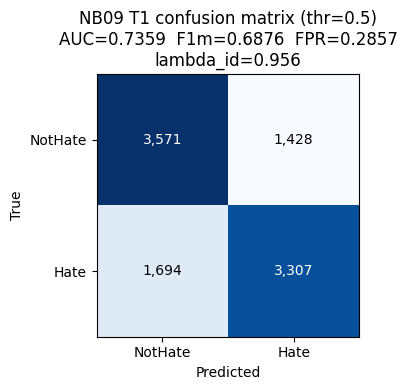

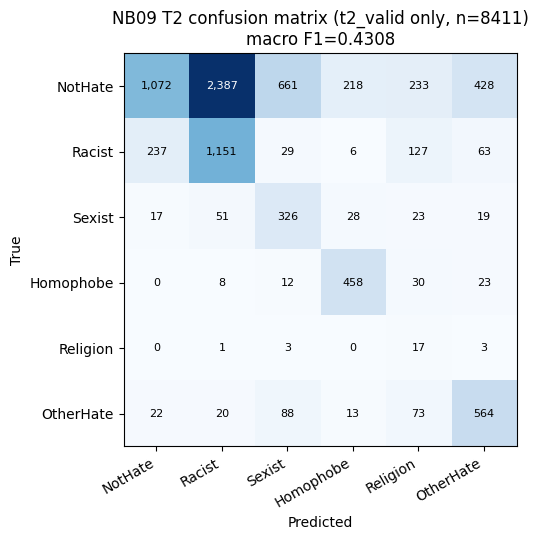

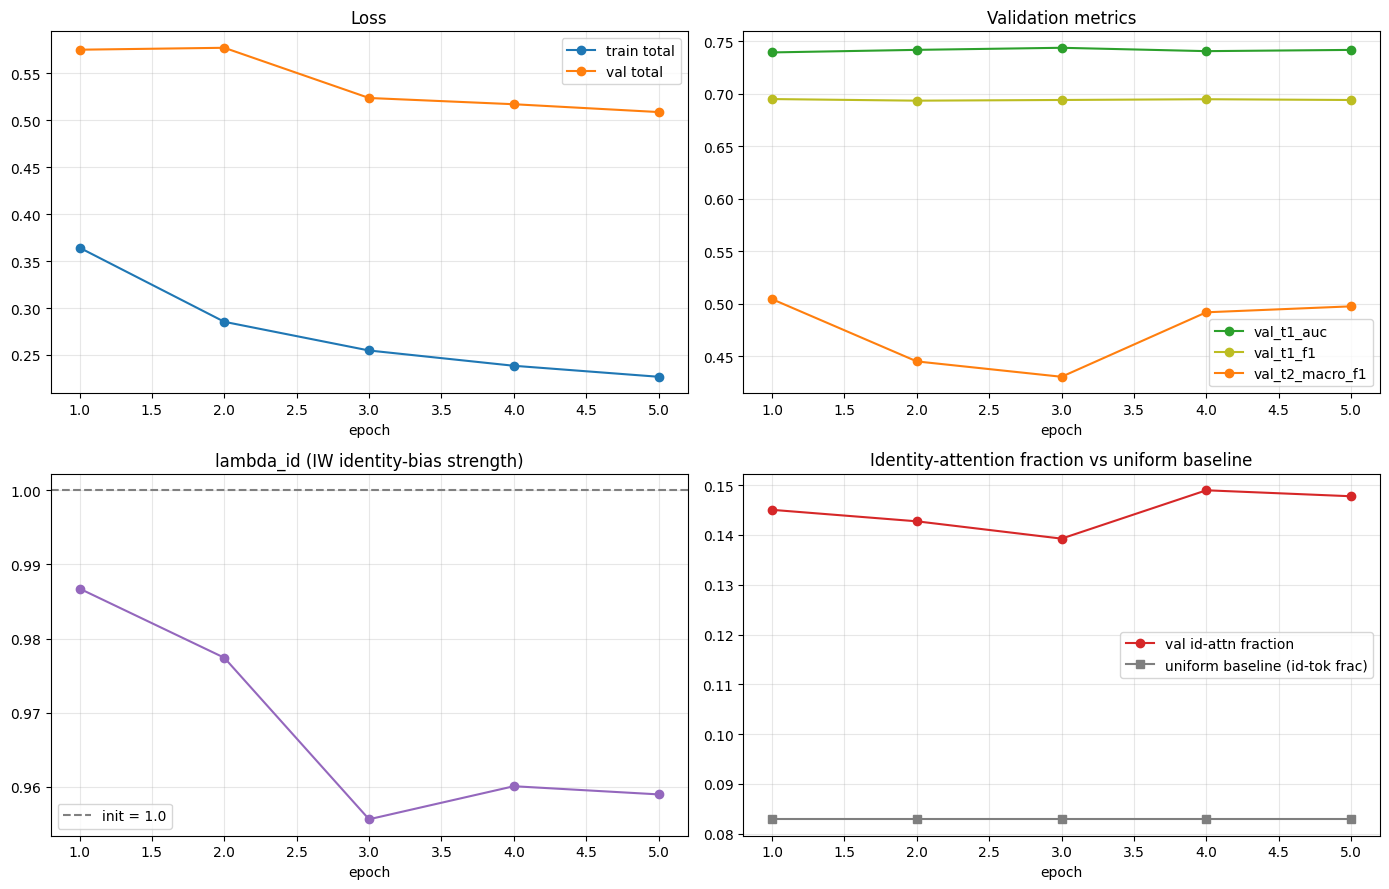

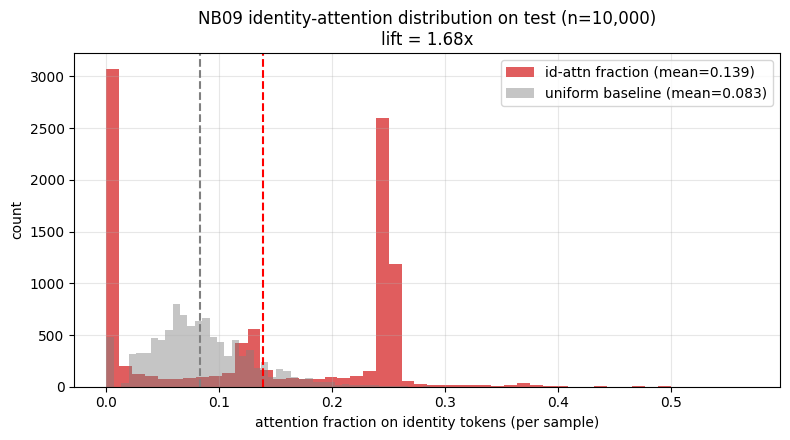

charts saved.


In [12]:
rest = torch.load(BEST_DIR / 'mvp4_iw_trainable.pt', map_location='cpu', weights_only=False)
model.struct_branch.load_state_dict(rest['struct_branch'])
model.cross_attn.load_state_dict(rest['cross_attn'])
model.cross_attn_ln.load_state_dict(rest['cross_attn_ln'])
model.gate.load_state_dict(rest['gate'])
model.proj_text.load_state_dict(rest['proj_text'])
model.proj_image.load_state_dict(rest['proj_image'])
model.proj_struct.load_state_dict(rest['proj_struct'])
model.head_t1.load_state_dict(rest['head_t1'])
model.head_t2.load_state_dict(rest['head_t2'])
model.to(device).eval()
lambda_id_final = float(model.cross_attn.lambda_id.detach().item())
print(f'reloaded best (epoch {rest["epoch"]}, val_t1_auc={rest["val_t1_auc"]:.4f}, '
      f'val_t2_macro_f1={rest["val_t2_macro_f1"]:.4f}, val_gate_H={rest["val_gate_H"]:.4f})')
print(f'lambda_id (loaded): {lambda_id_final:.4f}')

t1_probs, t1_true = [], []
t2_preds, t2_true, t2_valid_arr = [], [], []
all_gates, tweet_ids_out = [], []
id_attn_fracs, uniform_baselines = [], []
with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.float16):
    for batch in test_loader:
        ids  = batch['input_ids'].to(device, non_blocking=True)
        msk  = batch['attention_mask'].to(device, non_blocking=True)
        idm  = batch['identity_mask'].to(device, non_blocking=True)
        pix  = batch['pixel_values'].to(device, non_blocking=True)
        stc  = batch['structured'].to(device, non_blocking=True)
        logit_t1, logits_t2, gates, lam_id, attn = model(ids, msk, pix, stc, idm, return_attn=True)
        t1_probs.append(torch.sigmoid(logit_t1.view(-1).float()).cpu().numpy())
        t1_true.append(batch['t1_label'].cpu().numpy())
        t2_preds.append(logits_t2.argmax(dim=-1).cpu().numpy())
        t2_true.append(batch['t2_label'].cpu().numpy())
        t2_valid_arr.append(batch['t2_valid_mask'].cpu().numpy())
        all_gates.append(gates.float().cpu().numpy())
        tweet_ids_out.append(batch['tweet_id'].cpu().numpy())
        attn_mean = attn.float().mean(dim=1).squeeze(1)  # (B, Lk)
        frac = (attn_mean * idm.float()).sum(dim=-1).cpu().numpy()
        base = (idm.float().sum(dim=-1) / msk.float().sum(dim=-1).clamp(min=1)).cpu().numpy()
        id_attn_fracs.append(frac); uniform_baselines.append(base)

all_t1_probs = np.concatenate(t1_probs); all_t1_true = np.concatenate(t1_true)
all_t2_preds = np.concatenate(t2_preds); all_t2_true = np.concatenate(t2_true); all_t2_valid = np.concatenate(t2_valid_arr)
all_gates    = np.concatenate(all_gates, axis=0)
all_tweet_ids = np.concatenate(tweet_ids_out)
all_id_attn  = np.concatenate(id_attn_fracs)
all_uniform  = np.concatenate(uniform_baselines)
print(f'test preds: t1 {all_t1_probs.shape}, gates {all_gates.shape}, id_attn {all_id_attn.shape}')

# --- T1 metrics at threshold 0.5 ---
thr = HPARAMS['threshold']
all_t1_pred = (all_t1_probs >= thr).astype(int)
auc = roc_auc_score(all_t1_true, all_t1_probs)
f1m = f1_score(all_t1_true, all_t1_pred, average='macro')
pm  = precision_score(all_t1_true, all_t1_pred, average='macro', zero_division=0)
rm  = recall_score(all_t1_true, all_t1_pred, average='macro', zero_division=0)
cm  = confusion_matrix(all_t1_true, all_t1_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
fpr = fp / max(fp + tn, 1)
m_bal = {'AUC': float(auc), 'F1m': float(f1m), 'Pm': float(pm), 'Rm': float(rm), 'FPR': float(fpr),
         'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp)}
print(f'\n--- T1 BALANCED-TEST metrics (thr={thr}) ---')
for k, v in m_bal.items():
    if isinstance(v, float): print(f'  {k:<5} {v:.4f}')
    else:                    print(f'  {k:<5} {v}')

# --- T2 metrics ---
mask = all_t2_valid.astype(bool)
if mask.sum() > 0:
    t2_macro = f1_score(all_t2_true[mask], all_t2_preds[mask], average='macro',
                         labels=list(range(HPARAMS['n_t2_classes'])), zero_division=0)
    per_class = f1_score(all_t2_true[mask], all_t2_preds[mask], average=None,
                          labels=list(range(HPARAMS['n_t2_classes'])), zero_division=0)
    cm_t2 = confusion_matrix(all_t2_true[mask], all_t2_preds[mask],
                              labels=list(range(HPARAMS['n_t2_classes'])))
    print(f'\n--- T2 metrics (t2_valid=True only, n={int(mask.sum())}) ---')
    print(f'  macro F1: {t2_macro:.4f}')
    t2_classes = ['NotHate', 'Racist', 'Sexist', 'Homophobe', 'Religion', 'OtherHate']
    for c, f1c in zip(t2_classes, per_class):
        print(f'  per-class F1  {c:<10} = {f1c:.4f}')
else:
    t2_macro = float('nan'); per_class = np.full(HPARAMS['n_t2_classes'], np.nan); cm_t2 = None

# --- Gate stats ---
g_mean_test = all_gates.mean(axis=0)
g_std_test  = all_gates.std(axis=0)
gate_H_test = -(all_gates * np.log(all_gates + 1e-8)).sum(axis=-1)
print(f'\n--- TEST gate stats ---')
print(f'  mean: text={g_mean_test[0]:.4f}  image={g_mean_test[1]:.4f}  struct={g_mean_test[2]:.4f}')
print(f'  mean entropy: {gate_H_test.mean():.4f}  (log(3)={float(np.log(3.0)):.4f})')

# --- Identity-attention analysis ---
print(f'\n--- IDENTITY-ATTENTION ANALYSIS ---')
print(f'  lambda_id (final, loaded best): {lambda_id_final:.4f}')
print(f'  per-sample identity-attention fraction (test):')
print(f'    mean   = {all_id_attn.mean():.4f}')
print(f'    std    = {all_id_attn.std():.4f}')
print(f'    median = {float(np.median(all_id_attn)):.4f}')
print(f'    min    = {all_id_attn.min():.4f}  max = {all_id_attn.max():.4f}')
print(f'  uniform baseline (identity-token fraction in text):')
print(f'    mean   = {all_uniform.mean():.4f}')
print(f'  LIFT (id_attn / uniform): {all_id_attn.mean() / max(all_uniform.mean(), 1e-8):.2f}x')
over_indexing = all_id_attn.mean() > all_uniform.mean()
print(f'  Over-indexing on identity tokens? {"YES" if over_indexing else "NO"}')

# --- Save artefacts ---
np.save(MODEL_DIR / 'test_gates.npy',
        np.stack([all_tweet_ids.astype(np.int64),
                  all_gates[:, 0].astype(np.float32),
                  all_gates[:, 1].astype(np.float32),
                  all_gates[:, 2].astype(np.float32)], axis=1))
np.save(MODEL_DIR / 'test_identity_attention.npy',
        np.stack([all_tweet_ids.astype(np.int64),
                  all_id_attn.astype(np.float32),
                  all_uniform.astype(np.float32)], axis=1))
print(f'\nsaved test_gates.npy + test_identity_attention.npy to {MODEL_DIR}')

# --- Charts ---
# T1 confusion matrix
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap='Blues')
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, f'{v:,}', ha='center', va='center', color='black' if v < cm.max()/2 else 'white')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['NotHate', 'Hate']); ax.set_yticklabels(['NotHate', 'Hate'])
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'NB09 T1 confusion matrix (thr={thr})\nAUC={auc:.4f}  F1m={f1m:.4f}  FPR={fpr:.4f}\nlambda_id={lambda_id_final:.3f}')
plt.tight_layout()
plt.savefig(OUT_DIR / 'nb09_t1_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

# T2 confusion matrix
if cm_t2 is not None:
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    im = ax.imshow(cm_t2, cmap='Blues')
    t2_classes = ['NotHate', 'Racist', 'Sexist', 'Homophobe', 'Religion', 'OtherHate']
    for (i, j), v in np.ndenumerate(cm_t2):
        ax.text(j, i, f'{v:,}', ha='center', va='center',
                color='black' if v < cm_t2.max()/2 else 'white', fontsize=8)
    ax.set_xticks(range(HPARAMS['n_t2_classes'])); ax.set_yticks(range(HPARAMS['n_t2_classes']))
    ax.set_xticklabels(t2_classes, rotation=30, ha='right')
    ax.set_yticklabels(t2_classes)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'NB09 T2 confusion matrix (t2_valid only, n={int(mask.sum())})\nmacro F1={t2_macro:.4f}')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'nb09_t2_confusion_matrix.png', dpi=120, bbox_inches='tight')
    plt.show()

# Training curves
hist = history; ep = hist['epoch']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes[0, 0].plot(ep, hist['train_total'], label='train total', marker='o')
axes[0, 0].plot(ep, hist['val_total'],   label='val total',   marker='o')
axes[0, 0].set_title('Loss'); axes[0, 0].set_xlabel('epoch'); axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)
axes[0, 1].plot(ep, hist['val_t1_auc'], label='val_t1_auc',  marker='o', color='tab:green')
axes[0, 1].plot(ep, hist['val_t1_f1'],  label='val_t1_f1',   marker='o', color='tab:olive')
axes[0, 1].plot(ep, hist['val_t2_macro_f1'], label='val_t2_macro_f1', marker='o', color='tab:orange')
axes[0, 1].set_title('Validation metrics'); axes[0, 1].set_xlabel('epoch'); axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)
axes[1, 0].plot(ep, hist['lambda_id'], marker='o', color='tab:purple')
axes[1, 0].axhline(HPARAMS['lambda_id_init'], color='gray', linestyle='--', label=f'init = {HPARAMS["lambda_id_init"]}')
axes[1, 0].set_title('lambda_id (IW identity-bias strength)'); axes[1, 0].set_xlabel('epoch')
axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)
axes[1, 1].plot(ep, hist['val_id_attn_frac_mean'], label='val id-attn fraction', marker='o', color='tab:red')
axes[1, 1].plot(ep, hist['val_uniform_baseline_mean'], label='uniform baseline (id-tok frac)', marker='s', color='tab:gray')
axes[1, 1].set_title('Identity-attention fraction vs uniform baseline'); axes[1, 1].set_xlabel('epoch')
axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'nb09_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

# Identity-attention distribution
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(all_id_attn, bins=50, alpha=0.75, label=f'id-attn fraction (mean={all_id_attn.mean():.3f})', color='tab:red')
ax.hist(all_uniform, bins=50, alpha=0.45, label=f'uniform baseline (mean={all_uniform.mean():.3f})', color='tab:gray')
ax.axvline(all_id_attn.mean(), color='red', linestyle='--')
ax.axvline(all_uniform.mean(), color='gray', linestyle='--')
ax.set_xlabel('attention fraction on identity tokens (per sample)'); ax.set_ylabel('count')
ax.set_title(f'NB09 identity-attention distribution on test (n={len(all_id_attn):,})\nlift = {all_id_attn.mean()/max(all_uniform.mean(),1e-8):.2f}x')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'nb09_attention_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print('charts saved.')


In [13]:
prior_hate    = HPARAMS['prior_hate']
prior_nothate = HPARAMS['prior_nothate']

def recalibrate(p, ph=prior_hate, pn=prior_nothate):
    num = p * ph
    den = num + (1 - p) * pn
    return num / np.maximum(den, 1e-12)

v_probs, v_true = [], []
with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.float16):
    for batch in val_loader:
        ids = batch['input_ids'].to(device, non_blocking=True)
        msk = batch['attention_mask'].to(device, non_blocking=True)
        idm = batch['identity_mask'].to(device, non_blocking=True)
        pix = batch['pixel_values'].to(device, non_blocking=True)
        stc = batch['structured'].to(device, non_blocking=True)
        logit_t1, _, _, _ = model(ids, msk, pix, stc, idm)
        v_probs.append(torch.sigmoid(logit_t1.view(-1).float()).cpu().numpy())
        v_true.append(batch['t1_label'].cpu().numpy())
val_probs_arr = np.concatenate(v_probs); val_true_arr = np.concatenate(v_true)

test_probs_recal = recalibrate(all_t1_probs)
val_probs_recal  = recalibrate(val_probs_arr)

best_thr, best_thr_f1 = 0.5, -1.0
for t in np.linspace(0.01, 0.99, 99):
    pred = (val_probs_recal >= t).astype(int)
    fv = f1_score(val_true_arr, pred)
    if fv > best_thr_f1:
        best_thr_f1 = fv; best_thr = float(t)
print(f'F1-opt threshold on RECALIBRATED VAL: {best_thr:.3f} (val F1={best_thr_f1:.4f})')
print(f'  recal val prob range:  [{val_probs_recal.min():.4f}, {val_probs_recal.max():.4f}]  mean={val_probs_recal.mean():.4f}')
print(f'  recal test prob range: [{test_probs_recal.min():.4f}, {test_probs_recal.max():.4f}]  mean={test_probs_recal.mean():.4f}')

pred_recal = (test_probs_recal >= best_thr).astype(int)
auc_r = roc_auc_score(all_t1_true, test_probs_recal)
f1m_r = f1_score(all_t1_true, pred_recal, average='macro')
pm_r  = precision_score(all_t1_true, pred_recal, average='macro', zero_division=0)
rm_r  = recall_score(all_t1_true, pred_recal, average='macro', zero_division=0)
cm_r  = confusion_matrix(all_t1_true, pred_recal, labels=[0, 1])
tn_r, fp_r, fn_r, tp_r = cm_r.ravel()
fpr_r = fp_r / max(fp_r + tn_r, 1)
m_rec = {'AUC': float(auc_r), 'F1m': float(f1m_r), 'Pm': float(pm_r), 'Rm': float(rm_r), 'FPR': float(fpr_r),
         'TN': int(tn_r), 'FP': int(fp_r), 'FN': int(fn_r), 'TP': int(tp_r), 'threshold': float(best_thr)}

print('\n--- BALANCED-TEST  vs  RECALIBRATED-TEST  T1 metrics ---')
print(f'  {"":<7} {"balanced (thr=0.5)":>22} {"recalibrated (thr opt)":>24}')
for k in ['AUC', 'F1m', 'Pm', 'Rm', 'FPR']:
    print(f'  {k:<7} {m_bal[k]:>22.4f} {m_rec[k]:>24.4f}')
print(f'  CM bal: TN={m_bal["TN"]} FP={m_bal["FP"]} FN={m_bal["FN"]} TP={m_bal["TP"]}')
print(f'  CM rec: TN={m_rec["TN"]} FP={m_rec["FP"]} FN={m_rec["FN"]} TP={m_rec["TP"]} (thr={best_thr:.3f})')


F1-opt threshold on RECALIBRATED VAL: 0.220 (val F1=0.7057)
  recal val prob range:  [0.0523, 0.4163]  mean=0.2474
  recal test prob range: [0.0553, 0.4162]  mean=0.2486

--- BALANCED-TEST  vs  RECALIBRATED-TEST  T1 metrics ---
              balanced (thr=0.5)   recalibrated (thr opt)
  AUC                     0.7359                   0.7359
  F1m                     0.6876                   0.6821
  Pm                      0.6883                   0.6834
  Rm                      0.6878                   0.6825
  FPR                     0.2857                   0.3535
  CM bal: TN=3571 FP=1428 FN=1694 TP=3307
  CM rec: TN=3232 FP=1767 FN=1408 TP=3593 (thr=0.220)


In [14]:
mvp1   = {'AUC': 0.7431, 'F1m': 0.6855, 'FPR': 0.2667, 'label': 'MVP 1 (text-only)'}
mvp2   = {'AUC': 0.7411, 'F1m': 0.6892, 'FPR': 0.3041, 'label': 'MVP 2 (T+I naive)'}
mvp3   = {'AUC': 0.7406, 'F1m': 0.6905, 'FPR': 0.3361, 'label': 'MVP 3 (T+I+S naive)'}
mvp4   = {'AUC': 0.7400, 'F1m': 0.6888, 'FPR': 0.3071, 'label': 'MVP 4 (gated, lambda_ent=0.05)'}
this   = {'AUC': m_bal['AUC'], 'F1m': m_bal['F1m'], 'FPR': m_bal['FPR'], 'label': 'MVP 4-IW (this run)'}

def delta(a, b): return a - b
rows = [mvp1, mvp2, mvp3, mvp4, this]
print('=== MVP 1 / 2 / 3 / 4 / 4-IW comparison (balanced 50/50 test, thr=0.5) ===')
print(f'  {"":<32} {"AUC":>8} {"F1m":>8} {"FPR":>8}')
for r in rows:
    print(f'  {r["label"]:<32} {r["AUC"]:>8.4f} {r["F1m"]:>8.4f} {r["FPR"]:>8.4f}')
print('\n  Deltas (MVP 4-IW - baseline):')
for base in [mvp1, mvp2, mvp3, mvp4]:
    print(f'    vs {base["label"]:<32}  d_AUC={delta(this["AUC"], base["AUC"]):+.4f}  d_F1m={delta(this["F1m"], base["F1m"]):+.4f}  d_FPR={delta(this["FPR"], base["FPR"]):+.4f}')

# IW-specific metrics
print('\n=== IW-SPECIFIC METRICS ===')
print(f'  Final lambda_id (loaded best ckpt):  {lambda_id_final:.4f}')
print(f'  Mean identity-attention fraction:    {all_id_attn.mean():.4f}')
print(f'  Mean uniform baseline:               {all_uniform.mean():.4f}')
print(f'  Lift (id-attn / uniform):            {all_id_attn.mean()/max(all_uniform.mean(),1e-8):.2f}x')

# Three-axis verdict
NOISE = 0.005
auc_lift_vs_best = this['AUC'] - max(mvp1['AUC'], mvp2['AUC'], mvp3['AUC'], mvp4['AUC'])
fpr_drop_vs_mvp2 = mvp2['FPR'] - this['FPR']
auc_pass = auc_lift_vs_best > NOISE
fpr_pass = this['FPR'] < mvp2['FPR'] - NOISE
iw_active = all_id_attn.mean() > all_uniform.mean()
print('\n=== VERDICT (three-axis success criterion) ===')
print(f'  (a) AUC lift over best baseline: {auc_lift_vs_best:+.4f}  -> {"PASS" if auc_pass else "fail"} (need > +{NOISE:.3f})')
print(f'  (b) FPR drop below MVP 2:        {fpr_drop_vs_mvp2:+.4f}  -> {"PASS" if fpr_pass else "fail"} (need > +{NOISE:.3f})')
print(f'  (c) IW mechanism over-indexes:   {"YES" if iw_active else "no"}  (id-attn {all_id_attn.mean():.4f} vs uniform {all_uniform.mean():.4f})')
n_pass = int(auc_pass) + int(fpr_pass) + int(iw_active)
if n_pass >= 1:
    verdict = (f'HYPOTHESIS PARTIALLY OR FULLY SUPPORTED. {n_pass}/3 success axes passed: '
               f'AUC={"PASS" if auc_pass else "fail"}, FPR={"PASS" if fpr_pass else "fail"}, IW={"YES" if iw_active else "no"}.')
else:
    verdict = ('HYPOTHESIS NOT SUPPORTED. Neither AUC nor FPR improved over the prior best, '
               'and the IW mechanism did not over-index on identity tokens (mechanism dormant).')
print(f'\n  VERDICT: {verdict}')

# Save artefacts
shutil.copy(BEST_DIR / 'mvp4_iw_trainable.pt', MODEL_DIR / 'mvp4_iw_trainable.pt')
shutil.copy(BEST_DIR / 'standardisation_stats.json', MODEL_DIR / 'standardisation_stats.json')

with open(MODEL_DIR / 'hparams.json', 'w') as f:
    json.dump({k: v for k, v in HPARAMS.items() if not k.startswith('_')}, f, indent=2)
with open(MODEL_DIR / 'training_history.json', 'w') as f:
    json.dump(history, f, indent=2)

metrics_payload = {
    'run_label': 'mvp4_iw_attention',
    'best_epoch': int(best_epoch),
    'best_val_t1_auc': float(best_t1_auc),
    'best_val_t2_macro_f1': float(history['val_t2_macro_f1'][best_epoch - 1]) if best_epoch >= 1 else None,
    't1_pos_weight': float(pos_weight_value),
    't1_thresholds': {'balanced_headline': 0.5, 'recal_f1_optimised_on_recal_val': float(best_thr)},
    'priors_for_recalibration': {'hate': prior_hate, 'nothate': prior_nothate},
    't1_balanced_test_thr_0.5':       m_bal,
    't1_recalibrated_test_thr_opt':   m_rec,
    't2_test_macro_f1_valid_only':    float(t2_macro),
    't2_test_n_valid':                int(mask.sum()),
    'loss_weights': {'t1': HPARAMS['t1_weight'], 't2': HPARAMS['t2_weight'], 'entropy': HPARAMS['entropy_weight']},
    'iw_specific': {
        'lambda_id_init':             float(HPARAMS['lambda_id_init']),
        'lambda_id_final':            lambda_id_final,
        'mean_identity_attention_fraction_test': float(all_id_attn.mean()),
        'std_identity_attention_fraction_test':  float(all_id_attn.std()),
        'median_identity_attention_fraction_test': float(np.median(all_id_attn)),
        'mean_uniform_baseline_test': float(all_uniform.mean()),
        'lift':                       float(all_id_attn.mean() / max(all_uniform.mean(), 1e-8)),
        'over_indexing':              bool(iw_active),
    },
    'comparison': {
        'mvp1': mvp1, 'mvp2': mvp2, 'mvp3': mvp3, 'mvp4': mvp4, 'mvp4_iw': this,
        'auc_lift_vs_best_baseline': float(auc_lift_vs_best),
        'fpr_drop_vs_mvp2':          float(fpr_drop_vs_mvp2),
        'auc_pass': bool(auc_pass), 'fpr_pass': bool(fpr_pass), 'iw_active': bool(iw_active),
        'n_success_axes_passed':     int(n_pass),
        'verdict': verdict,
    },
}
with open(MODEL_DIR / 'metrics.json', 'w') as f:
    json.dump(metrics_payload, f, indent=2)

final_iw_stats = {
    'lambda_id_init': float(HPARAMS['lambda_id_init']),
    'lambda_id_final': lambda_id_final,
    'gate_mean':  {'text': float(g_mean_test[0]), 'image': float(g_mean_test[1]), 'struct': float(g_mean_test[2])},
    'gate_std':   {'text': float(g_std_test[0]),  'image': float(g_std_test[1]),  'struct': float(g_std_test[2])},
    'mean_gate_entropy_test': float(gate_H_test.mean()),
    'max_gate_entropy_log3':  float(np.log(3.0)),
    'mean_id_attention_fraction_test': float(all_id_attn.mean()),
    'mean_uniform_baseline_test':      float(all_uniform.mean()),
    'lift':                            float(all_id_attn.mean() / max(all_uniform.mean(), 1e-8)),
    'n_test': int(len(all_id_attn)),
}
with open(MODEL_DIR / 'final_iw_stats.json', 'w') as f:
    json.dump(final_iw_stats, f, indent=2)

print(f'\nartifacts saved to {MODEL_DIR}:')
for p in sorted(MODEL_DIR.iterdir()):
    sz_kb = p.stat().st_size / 1024
    print(f'  {p.name:<35} {sz_kb:>10.1f} KB')
print(f'best checkpoint:        {BEST_DIR / "mvp4_iw_trainable.pt"}')
print(f'per-sample test gates:  {MODEL_DIR / "test_gates.npy"}')
print(f'per-sample id-attention:{MODEL_DIR / "test_identity_attention.npy"}')
print('\nDONE.')


=== MVP 1 / 2 / 3 / 4 / 4-IW comparison (balanced 50/50 test, thr=0.5) ===
                                        AUC      F1m      FPR
  MVP 1 (text-only)                  0.7431   0.6855   0.2667
  MVP 2 (T+I naive)                  0.7411   0.6892   0.3041
  MVP 3 (T+I+S naive)                0.7406   0.6905   0.3361
  MVP 4 (gated, lambda_ent=0.05)     0.7400   0.6888   0.3071
  MVP 4-IW (this run)                0.7359   0.6876   0.2857

  Deltas (MVP 4-IW - baseline):
    vs MVP 1 (text-only)                 d_AUC=-0.0072  d_F1m=+0.0021  d_FPR=+0.0190
    vs MVP 2 (T+I naive)                 d_AUC=-0.0052  d_F1m=-0.0016  d_FPR=-0.0184
    vs MVP 3 (T+I+S naive)               d_AUC=-0.0047  d_F1m=-0.0029  d_FPR=-0.0504
    vs MVP 4 (gated, lambda_ent=0.05)    d_AUC=-0.0041  d_F1m=-0.0012  d_FPR=-0.0214

=== IW-SPECIFIC METRICS ===
  Final lambda_id (loaded best ckpt):  0.9556
  Mean identity-attention fraction:    0.1390
  Mean uniform baseline:               0.0830
  Lift (id-at